
# Clase 7 — Proyecto Integrador con Northwind

### 📘 Introducción al dataset Northwind

El conjunto de datos **Northwind** es un clásico utilizado en cursos de bases de datos y análisis. Representa la operación de una empresa ficticia de importación y exportación de alimentos, bebidas y productos especializados. Sus tablas reflejan diferentes aspectos del negocio: clientes, pedidos, productos, proveedores, empleados y categorías.

Para esta clase trabajaremos con un subconjunto de tablas principales:

* **Orders (`northwind_orders.csv`)**: información de cada pedido realizado, incluyendo la fecha, el cliente y el país de envío.
* **Order Details (`northwind_order_details.csv`)**: el detalle de los productos en cada pedido, con cantidad, precio unitario y descuento.

Estas tablas se relacionan entre sí a través de identificadores como `OrderID`, `ProductID` y `CustomerID`, lo que nos permitirá practicar **joins**, **agregaciones**, **limpieza de datos** y aplicar las técnicas de análisis que hemos aprendido en clases anteriores.

**Objetivos:**
- Explorar estructura y tipos de datos.
- Limpieza de NAs y normalización básica.
- Joins (`merge`), apilado (`concat`).
- Agregaciones con `groupby` + `.agg`.
- `apply` para clasificaciones.
- Documentar hallazgos en Markdown y exportar resultados.

**Entrega:** celdas de Markdown con tu análisis + CSVs generados.


In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


## 1) Carga de datos (Orders y Order Details obligatorios; Products y Customers opcionales)

In [2]:

# Rutas (ajústalas si es necesario)
ORDERS_CSV = "northwind_orders.csv"
DETAILS_CSV = "northwind_order_details.csv"

orders = pd.read_csv(ORDERS_CSV)
order_details = pd.read_csv(DETAILS_CSV)

products = pd.DataFrame({
    "ProductID": [1, 2, 3, 4],
    "ProductName": ["Chai", "Chang", "Aniseed Syrup", "Chef Anton's Cajun Seasoning"],
    "CategoryID": [1, 1, 2, 2],
    "Discontinued": [0, 0, 0, 0]
})

customers = pd.DataFrame({
    "CustomerID": ["ALFKI", "ANATR", "ANTON", "AROUT"],
    "CompanyName": ["Alfreds Futterkiste", "Ana Trujillo Emparedados", "Antonio Moreno Taquería", "Around the Horn"],
    "Country": ["Germany", "Mexico", "Mexico", "UK"],
    "Region": [np.nan, "DF", np.nan, "London"]
})


### ✍️ Ejercicio 1

Meta: revisar estructura, tipos, y valores faltantes.

- Escribe aquí tus observaciones:  
  - ¿Qué columnas parecen claves para unir tablas?  
  - ¿Qué columnas tienen NAs?  
  - ¿Detectas columnas numéricas que están como `object`?


In [3]:
orders.head(3)

,order_id,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postal_code,ship_country
0,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France
1,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany
2,10250,HANAR,4,1996-07-08,1996-08-05,1996-07-12,2,65.83,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,RJ,05454-876,Brazil


In [4]:
order_details.tail(7)

,order_id,product_id,unit_price,quantity,discount
2148,11077,55,24.00,2,0.00
2149,11077,60,34.00,2,0.06
2150,11077,64,33.25,2,0.03
2151,11077,66,17.00,1,0.00
2152,11077,73,15.00,2,0.01
2153,11077,75,7.75,4,0.00
2154,11077,77,13.00,2,0.00


In [5]:
order_details[order_details['order_id']==10248]

,order_id,product_id,unit_price,quantity,discount
0,10248,11,14.0,12,0.0
1,10248,42,9.8,10,0.0
2,10248,72,34.8,5,0.0


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          830 non-null    int64  
 1   customer_id       830 non-null    object 
 2   employee_id       830 non-null    int64  
 3   order_date        830 non-null    object 
 4   required_date     830 non-null    object 
 5   shipped_date      809 non-null    object 
 6   ship_via          830 non-null    int64  
 7   freight           830 non-null    float64
 8   ship_name         830 non-null    object 
 9   ship_address      830 non-null    object 
 10  ship_city         830 non-null    object 
 11  ship_region       323 non-null    object 
 12  ship_postal_code  811 non-null    object 
 13  ship_country      830 non-null    object 
dtypes: float64(1), int64(3), object(10)
memory usage: 90.9+ KB


In [7]:
order_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2155 entries, 0 to 2154
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    2155 non-null   int64  
 1   product_id  2155 non-null   int64  
 2   unit_price  2155 non-null   float64
 3   quantity    2155 non-null   int64  
 4   discount    2155 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 84.3 KB


In [8]:
order_details.describe()

,order_id,product_id,unit_price,quantity,discount
count,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000
mean,10659.375870,40.793039,26.218520,23.812993,0.056167
std,241.378032,22.159019,29.827418,19.022047,0.083450
min,10248.000000,1.000000,2.000000,1.000000,0.000000
25%,10451.000000,22.000000,12.000000,10.000000,0.000000
50%,10657.000000,41.000000,18.400000,20.000000,0.000000
75%,10862.500000,60.000000,32.000000,30.000000,0.100000
max,11077.000000,77.000000,263.500000,130.000000,0.250000



### ✍️ Ejercicio 2
Tipos y limpieza mínima

Meta: parsear fechas, coercionar números, tratamiento de valores NULL y dejar datos listos.

- Documenta en esta celda:
  - ¿Qué columnas normalizaste/convertiste?
  - ¿Qué estrategia aplicarías para valores faltantes (drop vs fill) y por qué?

In [9]:
orders['order_date']

0      1996-07-04
1      1996-07-05
2      1996-07-08
3      1996-07-08
4      1996-07-09
          ...    
825    1998-05-05
826    1998-05-06
827    1998-05-06
828    1998-05-06
829    1998-05-06
Name: order_date, Length: 830, dtype: object

In [10]:
# Método split, divide un string por un caracter, en este caso "b"
# NOTA el resultado es una lista
print("abcbd".split("b"))

print("1996-07-04".split("-"))

['a', 'c', 'd']
['1996', '07', '04']


In [11]:
# Pandas permite acceder a los métodos nativos de los strings por medio de "str"
orders['order_date'].str.split("-")

0      [1996, 07, 04]
1      [1996, 07, 05]
2      [1996, 07, 08]
3      [1996, 07, 08]
4      [1996, 07, 09]
            ...      
825    [1998, 05, 05]
826    [1998, 05, 06]
827    [1998, 05, 06]
828    [1998, 05, 06]
829    [1998, 05, 06]
Name: order_date, Length: 830, dtype: object

In [12]:
# List comprehension
#for x in orders['order_date'].str.split("-"):
#    print(x[0])

# Es un generador de listas
# [resultado for iterador in iterable]

years =  [x[0] for x in orders['order_date'].str.split("-")]
orders["year"] = years

orders

,order_id,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postal_code,ship_country,year
0,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France,1996
1,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany,1996
2,10250,HANAR,4,1996-07-08,1996-08-05,1996-07-12,2,65.83,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,RJ,05454-876,Brazil,1996
3,10251,VICTE,3,1996-07-08,1996-08-05,1996-07-15,1,41.34,Victuailles en stock,"2, rue du Commerce",Lyon,NaN,69004,France,1996
4,10252,SUPRD,4,1996-07-09,1996-08-06,1996-07-11,2,51.30,Suprêmes délices,"Boulevard Tirou, 255",Charleroi,NaN,B-6000,Belgium,1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,11073,PERIC,2,1998-05-05,1998-06-02,NaN,2,24.95,Pericles Comidas clásicas,Calle Dr. Jorge Cash 321,México D.F.,NaN,05033,Mexico,1998
826,11074,SIMOB,7,1998-05-06,1998-06-03,NaN,2,18.44,Simons bistro,Vinbæltet 34,Kobenhavn,NaN,1734,Denmark,1998
827,11075,RICSU,8,1998-05-06,1998-06-03,NaN,2,6.19,Richter Supermarkt,Starenweg 5,Genève,NaN,1204,Switzerland,1998
828,11076,BONAP,4,1998-05-06,1998-06-03,NaN,2,38.28,Bon app',"12, rue des Bouchers",Marseille,NaN,13008,France,1998


In [13]:
# Convertir una columna de fecha en datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['shipped_date'] = pd.to_datetime(orders['shipped_date'])
orders['required_date'] = pd.to_datetime(orders['required_date'])

In [14]:
# Cuando tengo una columna de tipo datetime, a través de "dt" voy a tener acceso a método de tiempo
orders['order_date'].dt.day
orders['order_date'].dt.month

orders["year"] = orders['order_date'].dt.year

orders

,order_id,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postal_code,ship_country,year
0,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France,1996
1,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany,1996
2,10250,HANAR,4,1996-07-08,1996-08-05,1996-07-12,2,65.83,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,RJ,05454-876,Brazil,1996
3,10251,VICTE,3,1996-07-08,1996-08-05,1996-07-15,1,41.34,Victuailles en stock,"2, rue du Commerce",Lyon,NaN,69004,France,1996
4,10252,SUPRD,4,1996-07-09,1996-08-06,1996-07-11,2,51.30,Suprêmes délices,"Boulevard Tirou, 255",Charleroi,NaN,B-6000,Belgium,1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,11073,PERIC,2,1998-05-05,1998-06-02,NaT,2,24.95,Pericles Comidas clásicas,Calle Dr. Jorge Cash 321,México D.F.,NaN,05033,Mexico,1998
826,11074,SIMOB,7,1998-05-06,1998-06-03,NaT,2,18.44,Simons bistro,Vinbæltet 34,Kobenhavn,NaN,1734,Denmark,1998
827,11075,RICSU,8,1998-05-06,1998-06-03,NaT,2,6.19,Richter Supermarkt,Starenweg 5,Genève,NaN,1204,Switzerland,1998
828,11076,BONAP,4,1998-05-06,1998-06-03,NaT,2,38.28,Bon app',"12, rue des Bouchers",Marseille,NaN,13008,France,1998


In [15]:
# En caso de ser requerido, podemos imputar (llenar) los NA con algún valor, en este caso un string "Unknown"
orders['ship_region'] = orders['ship_region'].fillna('Unknown')

In [16]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          830 non-null    int64         
 1   customer_id       830 non-null    object        
 2   employee_id       830 non-null    int64         
 3   order_date        830 non-null    datetime64[ns]
 4   required_date     830 non-null    datetime64[ns]
 5   shipped_date      809 non-null    datetime64[ns]
 6   ship_via          830 non-null    int64         
 7   freight           830 non-null    float64       
 8   ship_name         830 non-null    object        
 9   ship_address      830 non-null    object        
 10  ship_city         830 non-null    object        
 11  ship_region       830 non-null    object        
 12  ship_postal_code  811 non-null    object        
 13  ship_country      830 non-null    object        
 14  year              830 non-

### ✍️ Ejercicio 3

Meta: unir order_details con orders

- Explica qué filas podrían perderse o duplicarse con `inner`, `left` o `outer`.
- Cambia el tipo de join en una celda aparte y comenta diferencias de filas (shape).


In [17]:
orders.merge(order_details, on='order_id', how="left").shape

(2155, 19)

In [18]:
order_details.merge(orders, left_on='order_id', right_on='order_id', how="left").shape

(2155, 19)

In [19]:
orders.merge(order_details, on='order_id', how="left")

,order_id,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postal_code,ship_country,year,product_id,unit_price,quantity,discount
0,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,Unknown,51100,France,1996,11,14.00,12,0.00
1,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,Unknown,51100,France,1996,42,9.80,10,0.00
2,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,Unknown,51100,France,1996,72,34.80,5,0.00
3,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,Unknown,44087,Germany,1996,14,18.60,9,0.00
4,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,Unknown,44087,Germany,1996,51,42.40,40,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150,11077,RATTC,1,1998-05-06,1998-06-03,NaT,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,1998,64,33.25,2,0.03
2151,11077,RATTC,1,1998-05-06,1998-06-03,NaT,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,1998,66,17.00,1,0.00
2152,11077,RATTC,1,1998-05-06,1998-06-03,NaT,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,1998,73,15.00,2,0.01
2153,11077,RATTC,1,1998-05-06,1998-06-03,NaT,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,1998,75,7.75,4,0.00


In [20]:
order_details.merge(orders, left_on='order_id', right_on='order_id', how="left")

,order_id,product_id,unit_price,quantity,discount,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postal_code,ship_country,year
0,10248,11,14.00,12,0.00,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,Unknown,51100,France,1996
1,10248,42,9.80,10,0.00,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,Unknown,51100,France,1996
2,10248,72,34.80,5,0.00,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,Unknown,51100,France,1996
3,10249,14,18.60,9,0.00,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,Unknown,44087,Germany,1996
4,10249,51,42.40,40,0.00,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,Unknown,44087,Germany,1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150,11077,64,33.25,2,0.03,RATTC,1,1998-05-06,1998-06-03,NaT,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,1998
2151,11077,66,17.00,1,0.00,RATTC,1,1998-05-06,1998-06-03,NaT,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,1998
2152,11077,73,15.00,2,0.01,RATTC,1,1998-05-06,1998-06-03,NaT,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,1998
2153,11077,75,7.75,4,0.00,RATTC,1,1998-05-06,1998-06-03,NaT,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,1998


In [21]:
# Se recomienda hacer primero una selección de columnas, y después hacer el merge

orders_sub = orders[["order_id","ship_country"]]
order_details_sub = order_details[["order_id","product_id"]]

orders_ids = order_details_sub.merge(orders_sub)

# Reordenar columnas (en realidad, seleccionar columnas, pero lo hago en el orden que yo requiero)
orders_ids = orders_ids[["product_id","ship_country","order_id"]]
orders_ids

,product_id,ship_country,order_id
0,11,France,10248
1,42,France,10248
2,72,France,10248
3,14,Germany,10249
4,51,Germany,10249
...,...,...,...
2150,64,USA,11077
2151,66,USA,11077
2152,73,USA,11077
2153,75,USA,11077


### ✍️ Ejercicio 4

Meta: calcular revenue

- Explica cómo calculaste revenue (ingresos)

In [22]:
order_details['revenue'] = order_details['quantity'] * order_details['unit_price'] * (1 - order_details['discount'])
order_details

,order_id,product_id,unit_price,quantity,discount,revenue
0,10248,11,14.00,12,0.00,168.000
1,10248,42,9.80,10,0.00,98.000
2,10248,72,34.80,5,0.00,174.000
3,10249,14,18.60,9,0.00,167.400
4,10249,51,42.40,40,0.00,1696.000
...,...,...,...,...,...,...
2150,11077,64,33.25,2,0.03,64.505
2151,11077,66,17.00,1,0.00,17.000
2152,11077,73,15.00,2,0.01,29.700
2153,11077,75,7.75,4,0.00,31.000


**Nota** Para fines prácticos, siempre hacemos "reset_index" después de un group by por eliminar el indice calculado que nos deja Pandas

In [23]:
order_details[["order_id","revenue"]].groupby("order_id").sum().reset_index()

,order_id,revenue
0,10248,440.0000
1,10249,1863.4000
2,10250,1552.6000
3,10251,654.0600
4,10252,3597.9000
...,...,...
825,11073,300.0000
826,11074,232.0850
827,11075,498.1000
828,11076,792.7500


In [24]:
order_details.groupby("order_id")["revenue"].sum().reset_index()

,order_id,revenue
0,10248,440.0000
1,10249,1863.4000
2,10250,1552.6000
3,10251,654.0600
4,10252,3597.9000
...,...,...
825,11073,300.0000
826,11074,232.0850
827,11075,498.1000
828,11076,792.7500


### ✍️ Ejercicio 5

Meta: sumar revenue por país y por mes

Markdown:

Top 3 países por total. ¿Algún patrón temporal por mes?


In [ ]:
order_details['revenue'] = order_details['quantity'] * order_details['unit_price'] * (1 - order_details['discount'])

order_details_country = order_details.merge(orders[['ship_country','order_id', 'order_date']])
order_details_country["year"] = order_details_country["order_date"].dt.year
order_details_country["month"] = order_details_country["order_date"].dt.month

order_details_country.groupby('ship_country')['revenue'].sum().sort_values(ascending=False).head(3)

ship_country
USA        245584.6105
Germany    230284.6335
Austria    128003.8385
Name: revenue, dtype: float64

In [71]:
order_details_country["year-month"] = order_details_country["order_date"].dt.strftime("%Y-%m")

order_details_top3_country = order_details_country[order_details_country["ship_country"].isin(["USA","Germany","Austria"])]

order_details_top3_country = order_details_top3_country.groupby(["ship_country","year-month"])["revenue"].sum().reset_index()

In [72]:
# Tablas en formato "long"
# Este formato de tabla es el preferido para Tableau, Power BI y otras herramientas de BI
order_details_top3_country

,ship_country,year-month,revenue
0,Austria,1996-07,3488.6800
1,Austria,1996-11,15681.7850
2,Austria,1996-12,6430.8800
3,Austria,1997-01,9118.7150
4,Austria,1997-02,1792.0000
...,...,...,...
61,USA,1998-01,25620.5575
62,USA,1998-02,18462.4600
63,USA,1998-03,11860.2000
64,USA,1998-04,30175.5850


In [73]:
# Tablas en formato "wide"
# Es más fácil de comparar a la vista, y amigable para visualizar con Python y con Excel
order_details_top3_country = order_details_top3_country.pivot(index="year-month", columns="ship_country",values="revenue")

In [75]:
order_details_top3_country

ship_country,Austria,Germany,USA
year-month,,,
1996-07,3488.6800,6904.6500,1226.2000
1996-08,NaN,9518.8150,3391.6000
1996-09,NaN,2552.2000,9718.6000
1996-10,NaN,7553.0400,10788.6450
1996-11,15681.7850,6888.2400,4056.4800
1996-12,6430.8800,1990.2000,8924.1500
1997-01,9118.7150,3008.8000,4456.0000
1997-02,1792.0000,6691.5000,8697.6350
1997-03,439.2000,2229.6000,12268.0750


<Axes: xlabel='year-month'>

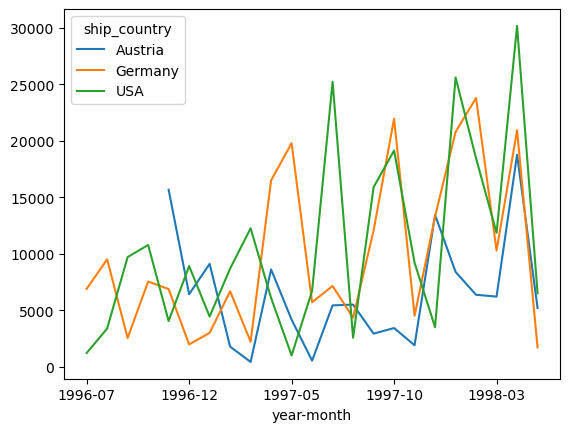

In [74]:
order_details_top3_country.plot()

### ✍️ Ejercicio 6

apply para clasificar pedidos y descuentos

Meta: crear “segmentos” útiles para análisis.

Markdown:

¿Qué países aplican más descuentos “high”?

¿Qué tamaño de pedido (S/M/L) concentra la mayor parte del revenue?

In [81]:
order_details_country = order_details.merge(orders[['ship_country','order_id', 'order_date']])

order_details_country_discount = order_details_country.groupby("ship_country")["discount"].mean().reset_index()

order_details_country_discount.describe()


,discount
count,21.000000
mean,0.049436
std,0.030295
min,0.000000
25%,0.032407
50%,0.055163
75%,0.066949
max,0.113636


In [93]:
def etiquetar_descuentos(x):
    # if x>=0.06:
    #     return "Alto"
    # elif x>=0.04:
    #     return "Medio"
    # else:
    #     return "Bajo"
    
    if x>=0.06: return "Alto"
    if x>=0.04: return "Medio"
    return "Bajo"

In [94]:
order_details_country_discount["discount_level"] = order_details_country_discount["discount"].apply(etiquetar_descuentos)

order_details_country_discount["discount_level"].value_counts()

discount_level
Alto     9
Bajo     8
Medio    4
Name: count, dtype: int64

### ✍️ Ejercicio 7

Exporta tus resultados

In [95]:
order_details_country_discount.to_excel("resultados.xlsx")


## Conclusiones finales (Markdown)
- Resume en 5–10 líneas tus hallazgos principales.
- Menciona decisiones de limpieza y su impacto.
- Anota 2–3 preguntas abiertas que te gustaría explorar con más tiempo.


In [101]:
fechas = pd.Series([20250930, 20251001])

In [105]:
pd.to_datetime(fechas,format="%Y%m%d")

0   2025-09-30
1   2025-10-01
dtype: datetime64[ns]